In [ ]:
from google.colab import drive 
drive.mount('/content/drive')

# Optimizers Modules

## 1. SGD Optimizer

In [2]:
import torch
import numpy as np
from torch.optim import Optimizer
import math

class SGD(Optimizer):
    """
    Enhanced SGD with Jupyter/GPU optimizations:
    - Better state management
    - Improved device compatibility
    - Efficient random sampling
    """
    def __init__(self, params, lr=1e-3, momentum=0, nesterov=False, 
                 weight_decay=0, lrd=1.0):
        defaults = dict(lr=lr, momentum=momentum, nesterov=nesterov,
                        weight_decay=weight_decay, lrd=lrd)
        super(SGD, self).__init__(params, defaults)

    def step(self):
        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None:
                    continue
                
                grad = p.grad.data
                state = self.state[p]
                
                # State initialization
                if len(state) == 0:
                    state['step'] = 0
                    if group['momentum'] != 0:
                        state['momentum_buffer'] = torch.zeros_like(p.data)
                    if group['nesterov']:
                        state['theta_buffer'] = torch.zeros_like(p.data)

                # Weight decay
                if group['weight_decay'] != 0:
                    grad.add_(group['weight_decay'], p.data)

                # Learning rate dropout
                if group['lrd'] < 1.0:
                    mask = (torch.rand_like(p.data) < group['lrd']).float()
                    mask = mask.to(p.device)
                else:
                    mask = 1.0

                # Momentum implementation
                if group['momentum'] != 0:
                    buf = state['momentum_buffer']
                    buf.mul_(group['momentum']).add_(grad)
                    
                    if group['nesterov']:
                        theta = state['theta_buffer']
                        theta.add_(mask * buf)
                        p.data = theta + group['momentum'] * buf
                    else:
                        p.data.add_(-group['lr'] * mask, buf)
                else:
                    p.data.add_(-group['lr'] * mask, grad)

                state['step'] += 1

## 2. Adam Optimizer

In [16]:
import torch
from torch.optim.optimizer import Optimizer
import math

class Adam(Optimizer):
    """
    Optimized Adam for Jupyter/GPU:
    - Correct weight decay handling
    - Efficient tensor operations
    - Better RAdam implementation
    """
    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8,
                 weight_decay=0, amsgrad=False, lrd=1.0, rectified=False):
        defaults = dict(lr=lr, betas=betas, eps=eps,
                        weight_decay=weight_decay, amsgrad=amsgrad,
                        lrd=lrd, rectified=rectified)
        super(Adam, self).__init__(params, defaults)

    def step(self):
        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None:
                    continue

                grad = p.grad.data
                if grad.is_sparse:
                    raise RuntimeError("Adam does not support sparse gradients.")

                state = self.state[p]

                # State initialization
                if len(state) == 0:
                    state['step'] = 0
                    state['exp_avg'] = torch.zeros_like(p.data)
                    state['exp_avg_sq'] = torch.zeros_like(p.data)
                    if group['amsgrad']:
                        state['max_exp_avg_sq'] = torch.zeros_like(p.data)

                exp_avg, exp_avg_sq = state['exp_avg'], state['exp_avg_sq']
                beta1, beta2 = group['betas']
                state['step'] += 1
                step = state['step']

                # Learning rate dropout mask
                if group['lrd'] < 1.0:
                    mask = (torch.rand_like(p.data) < group['lrd']).float().to(p.device)
                else:
                    mask = 1.0

                # Update biased first and second moment estimates
                exp_avg.mul_(beta1).add_(grad, alpha=1 - beta1)
                exp_avg_sq.mul_(beta2).addcmul_(grad, grad, value=1 - beta2)

                if group.get('rectified', False):
                    # RAdam variance rectification
                    rho_inf = 2 / (1 - beta2) - 1
                    beta2_t = beta2 ** step
                    rho_t = rho_inf - 2 * step * beta2_t / (1 - beta2_t)

                    if rho_t >= 5:
                        # Compute rectification factor rt safely
                        numerator = (1 - beta2_t) * (rho_t - 4) * (rho_t - 2) * rho_inf
                        denominator = (rho_inf - 4) * (rho_inf - 2) * rho_t
                        rt = torch.sqrt(torch.tensor(numerator / denominator, device=p.device, dtype=p.dtype))

                        denom = exp_avg_sq.sqrt().add_(group['eps'])
                        step_size = group['lr'] * rt
                    else:
                        step_size = group['lr'] / (1 - beta1 ** step)
                        denom = torch.tensor(1.0, device=p.device, dtype=p.dtype)  # Identity denom
                else:
                    # Vanilla Adam update
                    bias_correction1 = 1 - beta1 ** step
                    bias_correction2 = 1 - beta2 ** step
                    step_size = group['lr'] / bias_correction1
                    denom = (exp_avg_sq.sqrt() / math.sqrt(bias_correction2)).add_(group['eps'])

                # Parameter update
                p.data.addcdiv_(-step_size * mask, exp_avg, denom)

                # Weight decay (L2 regularization)
                if group['weight_decay'] != 0:
                    p.data.add_(-group['lr'] * group['weight_decay'], p.data)


## RMSProp Optimizer

In [4]:
class RMSProp(Optimizer):
    """
    Enhanced RMSProp with proper state management and GPU optimization
    """
    def __init__(self, params, lr=1e-2, alpha=0.99, eps=1e-8, 
                 weight_decay=0, momentum=0, lrd=1.0):
        defaults = dict(lr=lr, alpha=alpha, eps=eps, 
                        weight_decay=weight_decay, momentum=momentum,
                        lrd=lrd)
        super(RMSProp, self).__init__(params, defaults)

    def step(self):
        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None:
                    continue
                
                grad = p.grad.data
                state = self.state[p]

                # State initialization
                if len(state) == 0:
                    state['step'] = 0
                    state['square_avg'] = torch.zeros_like(p.data)
                    if group['momentum'] > 0:
                        state['momentum_buffer'] = torch.zeros_like(p.data)

                # Weight decay
                if group['weight_decay'] != 0:
                    grad.add_(group['weight_decay'], p.data)

                # Learning rate dropout
                if group['lrd'] < 1.0:
                    mask = (torch.rand_like(p.data) < group['lrd']).float()
                else:
                    mask = 1.0

                square_avg = state['square_avg']
                alpha = group['alpha']

                square_avg.mul_(alpha).addcmul_(1 - alpha, grad, grad)
                avg = square_avg.sqrt().add_(group['eps'])

                if group['momentum'] > 0:
                    buf = state['momentum_buffer']
                    buf.mul_(group['momentum']).addcdiv_(grad, avg)
                    p.data.add_(-group['lr'] * mask, buf)
                else:
                    p.data.addcdiv_(-group['lr'] * mask, grad, avg)

                state['step'] += 1

## 3. Gradient Noise, Lookahead Optimizer, Gradient Dropout Optimizer

In [5]:
from torch.optim import Optimizer
import math
import torch

class GradientNoise(Optimizer):
    def __init__(self, optimizer, eta=0.3, gamma=0.55):
        defaults = dict(eta=eta, gamma=gamma)
        super().__init__(optimizer.param_groups, defaults)
        self.optimizer = optimizer
        self._step = 0  # Global step counter

    def step(self):
        self._step += 1
        for group in self.param_groups:
            eta = group['eta']
            gamma = group['gamma']
            noise_std = math.sqrt(eta / (1 + self._step) ** gamma)
            
            for p in group['params']:
                if p.grad is None:
                    continue
                noise = torch.randn_like(p.grad) * noise_std
                p.grad.add_(noise)
        
        self.optimizer.step()

class Lookahead(Optimizer):
    def __init__(self, base_optimizer, k=5, alpha=0.5):
        defaults = dict(k=k, alpha=alpha)
        super().__init__(base_optimizer.param_groups, defaults)
        self.optimizer = base_optimizer
        self._init_slow_weights()

    def _init_slow_weights(self):
        for group in self.param_groups:
            for p in group['params']:
                self.state[p]['slow_weight'] = p.data.clone()
                self.state[p]['counter'] = 0

    def step(self):
        self.optimizer.step()
        
        for group in self.param_groups:
            k = group['k']
            alpha = group['alpha']
            
            for p in group['params']:
                state = self.state[p]
                state['counter'] += 1
                
                if state['counter'] % k == 0:
                    slow = state['slow_weight']
                    fast = p.data
                    slow.add_(alpha, fast - slow)
                    p.data.copy_(slow)
                    state['counter'] = 0

class GradientDropout(Optimizer):
    def __init__(self, optimizer, retain_prob=0.9):
        if not 0.0 <= retain_prob <= 1.0:
            raise ValueError(f"Invalid retain probability: {retain_prob}")
            
        defaults = dict(retain_prob=retain_prob)
        super().__init__(optimizer.param_groups, defaults)
        self.optimizer = optimizer

    def step(self):
        for group in self.param_groups:
            retain_prob = group['retain_prob']
            
            for p in group['params']:
                if p.grad is None:
                    continue
                if retain_prob < 1.0:
                    mask = (torch.rand_like(p.grad) < retain_prob).float()
                    p.grad.mul_(mask)
        
        self.optimizer.step()

## Networks Module(MLP, CNN based Deep Neural Net)

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm  # For Jupyter progress bars

class MLP(nn.Module):
    """
    Enhanced MLP with automatic input flattening and device awareness
    """
    def __init__(self, num_features=784, num_hidden=256, num_outputs=10):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(num_features, num_hidden),
            nn.ReLU(),
            nn.Linear(num_hidden, num_hidden),
            nn.ReLU(),
            nn.Linear(num_hidden, num_outputs)
        )
        
        # Initialize weights properly
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)

class CNN(nn.Module):
    """
    Improved CNN with adaptive pooling for flexible input sizes
    """
    def __init__(self, num_classes=10, num_filters=64):
        super().__init__()
        self.net = nn.Sequential(
            # Input: 3x32x32 for CIFAR-10
            nn.Conv2d(3, num_filters, 3, padding=1),
            nn.BatchNorm2d(num_filters),
            nn.ReLU(),
            nn.Conv2d(num_filters, num_filters, 3, padding=1),
            nn.BatchNorm2d(num_filters),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(num_filters, num_filters*2, 3, padding=1),
            nn.BatchNorm2d(num_filters*2),
            nn.ReLU(),
            nn.Conv2d(num_filters*2, num_filters*2, 3, padding=1),
            nn.BatchNorm2d(num_filters*2),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.AdaptiveAvgPool2d(1),  # Handles variable input sizes
            nn.Flatten(),
            nn.Linear(num_filters*2, num_classes)
        )

    def forward(self, x):
        return self.net(x)

def fit(net, train_data, val_data, optimizer, device, 
        batch_size=128, num_epochs=100, lr_schedule=False):
    """
    Enhanced training loop with:
    - Proper device management
    - Validation accuracy tracking
    - Progress bars
    - Gradient clipping
    """
    # Data loaders with persistent workers
    train_loader = DataLoader(train_data, batch_size=batch_size, 
                            shuffle=True, num_workers=4, pin_memory=True)
    val_loader = DataLoader(val_data, batch_size=batch_size*2, 
                          num_workers=4, pin_memory=True)

    # Metrics tracking
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_acc': []
    }
    
    # Learning rate scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, verbose=True) if lr_schedule else None

    # Main training loop
    for epoch in range(num_epochs):
        net.train()
        train_loss = 0.0
        
        # Training phase with progress bar
        for inputs, targets in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}'):
            inputs, targets = inputs.to(device), targets.to(device)
            
            # Forward pass
            optimizer.zero_grad()
            outputs = net(inputs)
            loss = F.cross_entropy(outputs, targets)
            
            # Backward pass
            loss.backward()
            torch.nn.utils.clip_grad_norm_(net.parameters(), 1.0)  # Gradient clipping
            optimizer.step()
            
            train_loss += loss.item() * inputs.size(0)

        # Validation phase
        net.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = net(inputs)
                loss = F.cross_entropy(outputs, targets)
                
                val_loss += loss.item() * inputs.size(0)
                _, predicted = outputs.max(1)
                correct += predicted.eq(targets).sum().item()
                total += targets.size(0)
        
        # Update metrics
        train_loss = train_loss / len(train_data)
        val_loss = val_loss / len(val_data)
        val_acc = 100. * correct / total
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        # Update learning rate
        if scheduler:
            scheduler.step(val_loss)
            
        # Print epoch summary
        print(f'Epoch {epoch+1:03d}: '
              f'Train Loss: {train_loss:.4f} | '
              f'Val Loss: {val_loss:.4f} | '
              f'Val Acc: {val_acc:.2f}%')

    return history

## Pytorch Dataset

In [9]:
import os
import pickle
from pathlib import Path
from copy import deepcopy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms
from tqdm.notebook import tqdm

# Configure default plotting style
sns.set(style="whitegrid", context="notebook", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
%matplotlib inline  

class OptimizationDataset(Dataset):
    """Improved dataset class with automatic tensor conversion and device awareness"""
    def __init__(self, X, y, transform=None, device="cuda"):
        self.X = torch.tensor(X, dtype=torch.float32).to(device)
        self.y = torch.tensor(y, dtype=torch.long).to(device)
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx]
        if self.transform:
            x = self.transform(x)
        return x, self.y[idx]

class MetricTracker:
    """Enhanced metric tracking with PyTorch tensor support and GPU awareness"""
    def __init__(self):
        self.values = []
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        
    def update(self, value):
        if isinstance(value, torch.Tensor):
            self.values.append(value.detach().to(self.device))
        else:
            self.values.append(torch.tensor(value, device=self.device))
    
    @property
    def mean(self):
        return torch.stack(self.values).mean().item() if self.values else 0
    
    @property
    def latest(self):
        return self.values[-1].item() if self.values else 0
    
    def reset(self):
        self.values = []

def load_cifar10(batch_size=128, num_workers=4, valid_ratio=0.1):
    """Improved CIFAR-10 loading with better normalization and augmentation"""
    normalize = transforms.Normalize(
        mean=[0.4914, 0.4822, 0.4465],
        std=[0.2470, 0.2435, 0.2616]
    )
    
    train_transform = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        normalize
    ])
    
    test_transform = transforms.Compose([
        transforms.ToTensor(),
        normalize
    ])
    
    full_train = torchvision.datasets.CIFAR10(
        root="/home/shubham24165/AOMML_A3/CIFAR_data", train=True, download=True, transform=train_transform)
    
    # Split validation set
    num_valid = int(len(full_train) * valid_ratio)
    num_train = len(full_train) - num_valid
    train_dataset, valid_dataset = torch.utils.data.random_split(
        full_train, [num_train, num_valid])
    
    test_dataset = torchvision.datasets.CIFAR10(
        root="/home/shubham24165/AOMML_A3/CIFAR_data", train=False, download=True, transform=test_transform)
    
    dataloaders = {
        "train": DataLoader(train_dataset, batch_size=batch_size,
                          shuffle=True, num_workers=num_workers, pin_memory=True),
        "valid": DataLoader(valid_dataset, batch_size=batch_size*2,
                          num_workers=num_workers, pin_memory=True),
        "test": DataLoader(test_dataset, batch_size=batch_size*2,
                         num_workers=num_workers, pin_memory=True)
    }
    return dataloaders

def load_mnist(batch_size=128, num_workers=4, valid_ratio=0.1):
    transform = transforms.ToTensor()
    
    full_train = torchvision.datasets.MNIST(
        root="/home/shubham24165/AOMML_A3/MNIST_data", train=True, download=True, transform=transform)
    
    num_valid = int(len(full_train) * valid_ratio)
    num_train = len(full_train) - num_valid
    train_dataset, valid_dataset = torch.utils.data.random_split(
        full_train, [num_train, num_valid])
    
    test_dataset = torchvision.datasets.MNIST(
        root="/home/shubham24165/AOMML_A3/MNIST_data", train=False, download=True, transform=transform)
    
    dataloaders = {
        "train": DataLoader(train_dataset, batch_size=batch_size,
                            shuffle=True, num_workers=num_workers, pin_memory=True),
        "valid": DataLoader(valid_dataset, batch_size=batch_size*2,
                            num_workers=num_workers, pin_memory=True),
        "test": DataLoader(test_dataset, batch_size=batch_size*2,
                           num_workers=num_workers, pin_memory=True)
    }
    return dataloaders
    
def visualize_performance(history_dict, title="Optimizer Comparison", save_path=None):
    plt.figure(figsize=(18, 7))

    # --- Loss subplot ---
    plt.subplot(1, 2, 1)
    for label, metrics in history_dict.items():
        train_loss = [v.item() if isinstance(v, torch.Tensor) else v for v in metrics["train_loss"]]
        val_loss = [v.item() if isinstance(v, torch.Tensor) else v for v in metrics["val_loss"]]
        plt.plot(train_loss, label=f"{label} Train", linestyle='-', marker='o', markersize=4)
        plt.plot(val_loss, label=f"{label} Val", linestyle='--', marker='x', markersize=4)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend()
    plt.grid(True)

    # --- Accuracy subplot ---
    plt.subplot(1, 2, 2)
    for label, metrics in history_dict.items():
        val_acc = [v.item() if isinstance(v, torch.Tensor) else v for v in metrics["val_acc"]]
        plt.plot(val_acc, label=f"{label} Val", linestyle='-', marker='s', markersize=4)
    plt.xlabel("Epochs")
    plt.ylabel("Validation Accuracy (%)")
    plt.title("Validation Accuracy Comparison")
    plt.legend()
    plt.grid(True)

    plt.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path)
        print(f"Saved visualization to {save_path}")
    else:
        plt.show()


def save_experiment(results, filename="experiment.pth"):
    """Safe experiment saving with path creation"""
    Path("results").mkdir(exist_ok=True)
    torch.save(results, f"results/{filename}")
    print(f"Saved experiment to results/{filename}")

def load_experiment(filename="experiment.pth"):
    """Experiment loading with device mapping"""
    return torch.load(f"results/{filename}", map_location="cuda" if torch.cuda.is_available() else "cpu")

# Updated optimizer configuration with modern defaults
OPTIM_CONFIG = {
    "sgd": {
        "label": "SGD",
        "lr": 0.1,
        "momentum": 0.9,
        "weight_decay": 5e-4,
        "lrd": 1.0
    },
    "adam": {
        "label": "Adam",
        "lr": 3e-4,
        "betas": (0.9, 0.999),
        "weight_decay": 0,
        "lrd": 1.0,
        "rectified": False
    },
    "adamw": {
        "label": "AdamW",
        "lr": 3e-4,
        "betas": (0.9, 0.999),
        "weight_decay": 0.01,
        "lrd": 1.0
    },
    "radam": {
        "label": "RAdam",
        "lr": 3e-4,
        "betas": (0.9, 0.999),
        "rectified": True,
        "lrd": 1.0
    },
    "lookahead_adam": {
        "label": "Lookahead (Adam)",
        "lr": 3e-4,
        "betas": (0.9, 0.999),
        "lrd": 1.0
    },
    "rmsprop": {
        "label": "RMSProp",
        "lr": 1e-2,
        "alpha": 0.99,
        "eps": 1e-8,
        "weight_decay": 0,
        "momentum": 0,  # adjust as needed
        "lrd": 1.0
    }
}
# Custom Optimizers 
def create_optimizer(model, config_name):
    config = OPTIM_CONFIG[config_name.lower()]
    base_optimizer = None

    if "sgd" in config_name.lower():
        base_optimizer = SGD(
            model.parameters(),
            lr=config["lr"],
            momentum=config.get("momentum", 0),
            weight_decay=config.get("weight_decay", 0),
            lrd=config.get("lrd", 1.0)
        )
    elif "adam" in config_name.lower() and "lookahead" not in config_name.lower():
        base_optimizer = Adam(
            model.parameters(),
            lr=config["lr"],
            betas=config.get("betas", (0.9, 0.999)),
            weight_decay=config.get("weight_decay", 0),
            lrd=config.get("lrd", 1.0),
            rectified=config.get("rectified", False)
        )
    elif "adamw" in config_name.lower():
        # You can either use your custom Adam with modifications
        # or implement a separate branch if needed.
        base_optimizer = Adam(
            model.parameters(),
            lr=config["lr"],
            betas=config.get("betas", (0.9, 0.999)),
            weight_decay=config.get("weight_decay", 0),
            lrd=config.get("lrd", 1.0),
            rectified=config.get("rectified", False)
        )
    elif "radam" in config_name.lower():
        base_optimizer = Adam(
            model.parameters(),
            lr=config["lr"],
            betas=config.get("betas", (0.9, 0.999)),
            weight_decay=config.get("weight_decay", 0),
            lrd=config.get("lrd", 1.0),
            rectified=True  # explicitly rectified
        )
    elif "lookahead" in config_name.lower():
        # Here, we assume the base is an Adam variant. You could also handle
        # other base optimizers if needed.
        base_optimizer = Adam(
            model.parameters(),
            lr=config["lr"],
            betas=config.get("betas", (0.9, 0.999)),
            weight_decay=config.get("weight_decay", 0),
            lrd=config.get("lrd", 1.0),
            rectified=config.get("rectified", False)
        )
        base_optimizer = Lookahead(base_optimizer)
    elif "rmsprop" in config_name.lower():
        base_optimizer = RMSProp(
            model.parameters(),
            lr=config["lr"],
            alpha=config.get("alpha", 0.99),
            eps=config.get("eps", 1e-8),
            weight_decay=config.get("weight_decay", 0),
            momentum=config.get("momentum", 0),
            lrd=config.get("lrd", 1.0)
        )
    else:
        raise ValueError("Optimizer not recognized!")
    
    return base_optimizer


# Pytorch Built-In Optimizers
    
# def create_optimizer(model, config_name):
#     """Factory function for creating optimizers with safety checks"""
#     config = OPTIM_CONFIG[config_name.lower()]
#     base_optimizer = None
    
#     if "sgd" in config_name.lower():
#         base_optimizer = torch.optim.SGD(
#             model.parameters(),
#             lr=config["lr"],
#             momentum=config.get("momentum", 0),
#             weight_decay=config.get("weight_decay", 0)
#         )
#     elif "adam" in config_name.lower():
#         base_optimizer = torch.optim.AdamW(
#             model.parameters(),
#             lr=config["lr"],
#             betas=config.get("betas", (0.9, 0.999)),
#             weight_decay=config.get("weight_decay", 0)
#         )
    
#     # Add wrapper optimizers
#     if "lookahead" in config_name.lower():
#         base_optimizer = Lookahead(base_optimizer)
    
#     return base_optimizer

## Train Pipeline

In [10]:
import torch
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from IPython.display import clear_output

def run_experiment(dataset='cifar', num_epochs=30, batch_size=128, 
                   optimizers_to_run='all', device=None):
    """
    Jupyter-optimized main training loop with live visualization and printing
    """
    device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    # Load data and model
    data_loaders = load_cifar10(batch_size=batch_size) if dataset == 'cifar' else load_mnist(batch_size=batch_size)
    model = CNN().to(device) if dataset == 'cifar' else MLP().to(device)
    
    # Configure optimizers
    optim_configs = OPTIM_CONFIG
    if optimizers_to_run != 'all':
        optim_configs = {k: v for k, v in optim_configs.items() if k in optimizers_to_run}
    
    # Training history storage
    history = {}

    # Live plotting setup
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    plt.ion()
    
    for opt_name, config in tqdm(optim_configs.items(), desc="Optimizers"):
        model.apply(weight_reset)
        optimizer = create_optimizer(model, opt_name)

        print(f"\n{'='*60}")
        print(f"Training with optimizer: {opt_name}")
        print(f"{'='*60}\n")

        history[opt_name] = {'train_loss': [], 'val_loss': [], 'val_acc': []}

        for epoch in tqdm(range(num_epochs), desc=f"Training {opt_name}"):
            train_metrics = train_epoch(model, data_loaders['train'], optimizer, device)
            val_metrics = validate(model, data_loaders['valid'], device)
            print(f"[{opt_name}] Epoch {epoch+1}/{num_epochs} | Train Loss: {train_metrics['loss']:.4f} | Val Loss: {val_metrics['loss']:.4f} | Val Acc: {val_metrics['accuracy']:.2f}")

            # Update history
            history[opt_name]['train_loss'].append(train_metrics['loss'])
            history[opt_name]['val_loss'].append(val_metrics['loss'])
            history[opt_name]['val_acc'].append(val_metrics['accuracy'])

            # Print per epoch summary
            print(f"Epoch {epoch+1}/{num_epochs} | "
                  f"Train Loss: {train_metrics['loss']:.4f} | "
                  f"Val Loss: {val_metrics['loss']:.4f} | "
                  f"Val Acc: {val_metrics['accuracy']*100:.2f}%")

            # Live plot update
            update_live_plot(ax1, ax2, history)

        save_experiment(history, f"{dataset}_{opt_name}.pth")

    # plt.ioff()
    plt.show()
    return history

def train_epoch(model, loader, optimizer, device):
    """GPU-optimized training epoch"""
    model.train()
    metrics = {'loss': 0, 'accuracy': 0}
    
    for inputs, targets in tqdm(loader, leave=False):
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = F.cross_entropy(outputs, targets)
        loss.backward()
        optimizer.step()
        
        metrics['loss'] += loss.item() * inputs.size(0)
        metrics['accuracy'] += (outputs.argmax(1) == targets).sum().item()
    
    metrics['loss'] /= len(loader.dataset)
    metrics['accuracy'] /= len(loader.dataset)
    return metrics

def validate(model, loader, device):
    """Validation phase with gradient disabled"""
    model.eval()
    metrics = {'loss': 0, 'accuracy': 0}
    
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            
            metrics['loss'] += F.cross_entropy(outputs, targets).item() * inputs.size(0)
            metrics['accuracy'] += (outputs.argmax(1) == targets).sum().item()
    
    metrics['loss'] /= len(loader.dataset)
    metrics['accuracy'] /= len(loader.dataset)
    return metrics

def weight_reset(m):
    """Resets model weights between optimizer trials"""
    if isinstance(m, (nn.Conv2d, nn.Linear)):
        m.reset_parameters()
        
def update_live_plot(ax1, ax2, history):
    from IPython.display import clear_output
    # clear_output(wait=True)

    # ax1.clear()
    # ax2.clear()

    for opt, metrics in history.items():
        ax1.plot(metrics['train_loss'], label=f"{opt} Train", marker='o', linewidth=1)
        ax1.plot(metrics['val_loss'], '--', label=f"{opt} Val", marker='x', linewidth=1)

    ax1.set_title('Loss Curves')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.grid(True)
    ax1.legend()

    for opt, metrics in history.items():
        ax2.plot(metrics['val_acc'], label=opt, marker='s', linewidth=1)

    ax2.set_title('Validation Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.grid(True)
    ax2.legend()

    plt.suptitle("Live Training Progress", fontsize=16)
    plt.tight_layout()
    plt.draw()
    plt.pause(0.001)  # ⬅️ Critical for real-time updates in notebook


In [11]:
pwd

'/home/shubham24165/AOMML_A3'

## Inference

In [12]:
# For CIFAR-10
train_dataset = torchvision.datasets.CIFAR10(
    root='/home/shubham24165/AOMML_A3/CIFAR_data',  # <-- Server directory where data will be stored
    train=True,
    download=True,  # <-- This triggers auto-download if missing
    transform=transforms.ToTensor()
)

# For MNIST
train_dataset = torchvision.datasets.MNIST(
    root='/home/shubham24165/AOMML_A3/MNIST_data',
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

100%|███████████████████████████████████████████████████████████████| 170498071/170498071 [00:16<00:00, 10139168.29it/s]


Extracting /home/shubham24165/AOMML_A3/CIFAR_data/cifar-10-python.tar.gz to /home/shubham24165/AOMML_A3/CIFAR_data
Failed to download (trying next):
HTTP Error 404: Not Found



100%|█████████████████████████████████████████████████████████████████████| 9912422/9912422 [00:11<00:00, 848250.82it/s]


Extracting /home/shubham24165/AOMML_A3/MNIST_data/MNIST/raw/train-images-idx3-ubyte.gz to /home/shubham24165/AOMML_A3/MNIST_data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████████████████████████████████████████████████████████████████████| 28881/28881 [00:00<00:00, 51967.60it/s]


Extracting /home/shubham24165/AOMML_A3/MNIST_data/MNIST/raw/train-labels-idx1-ubyte.gz to /home/shubham24165/AOMML_A3/MNIST_data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|████████████████████████████████████████████████████████████████████| 1648877/1648877 [00:01<00:00, 1029885.22it/s]


Extracting /home/shubham24165/AOMML_A3/MNIST_data/MNIST/raw/t10k-images-idx3-ubyte.gz to /home/shubham24165/AOMML_A3/MNIST_data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████████████████████████████████████████████████████████████████████| 4542/4542 [00:00<00:00, 1394417.27it/s]


Extracting /home/shubham24165/AOMML_A3/MNIST_data/MNIST/raw/t10k-labels-idx1-ubyte.gz to /home/shubham24165/AOMML_A3/MNIST_data/MNIST/raw



In [12]:
%matplotlib notebook

In [20]:
# %% Run Experiment with Live Plotting
history = run_experiment(
    dataset='cifar',
    num_epochs=50,
    optimizers_to_run=['sgd', 'adam', 'adamw', 'radam', 'lookahead_adam', 'rmsprop'],
    batch_size=256
)

# %% Save Results
save_experiment(history, filename='cifar_optim_custom.pth')

# %% Final Comparison Plot
visualize_performance(history, title='Optimizer Comparison on CIFAR-10', save_path='results/final_comparison.png')

# %% Load Previous Results (if needed)
# To load instead of re-running:
# history = load_experiment('cifar_optim_comparison.pth')
# visualize_performance(history, title='Loaded Optimizer Comparison')

Using device: cuda
Files already downloaded and verified
Files already downloaded and verified


<IPython.core.display.Javascript object>

Optimizers:   0%|          | 0/6 [00:00<?, ?it/s]


Training with optimizer: sgd



Training sgd:   0%|          | 0/50 [00:00<?, ?it/s]

...

[rmsprop] Epoch 49/50 | Train Loss: 0.4708 | Val Loss: 0.6997 | Val Acc: 0.76
Epoch 49/50 | Train Loss: 0.4708 | Val Loss: 0.6997 | Val Acc: 76.26%


  0%|          | 0/176 [00:00<?, ?it/s]

[rmsprop] Epoch 50/50 | Train Loss: 0.4637 | Val Loss: 0.8052 | Val Acc: 0.75
Epoch 50/50 | Train Loss: 0.4637 | Val Loss: 0.8052 | Val Acc: 74.54%
Saved experiment to results/cifar_rmsprop.pth
Saved experiment to results/cifar_optim_custom.pth


<IPython.core.display.Javascript object>

Saved visualization to results/final_comparison.png


/tmp/ipykernel_2249645/938116832.py:169: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(f"results/{filename}", map_location="cuda" if torch.cuda.is_availabl

Saved visualization to results/final_comparison.png


<Figure size 1200x600 with 0 Axes>

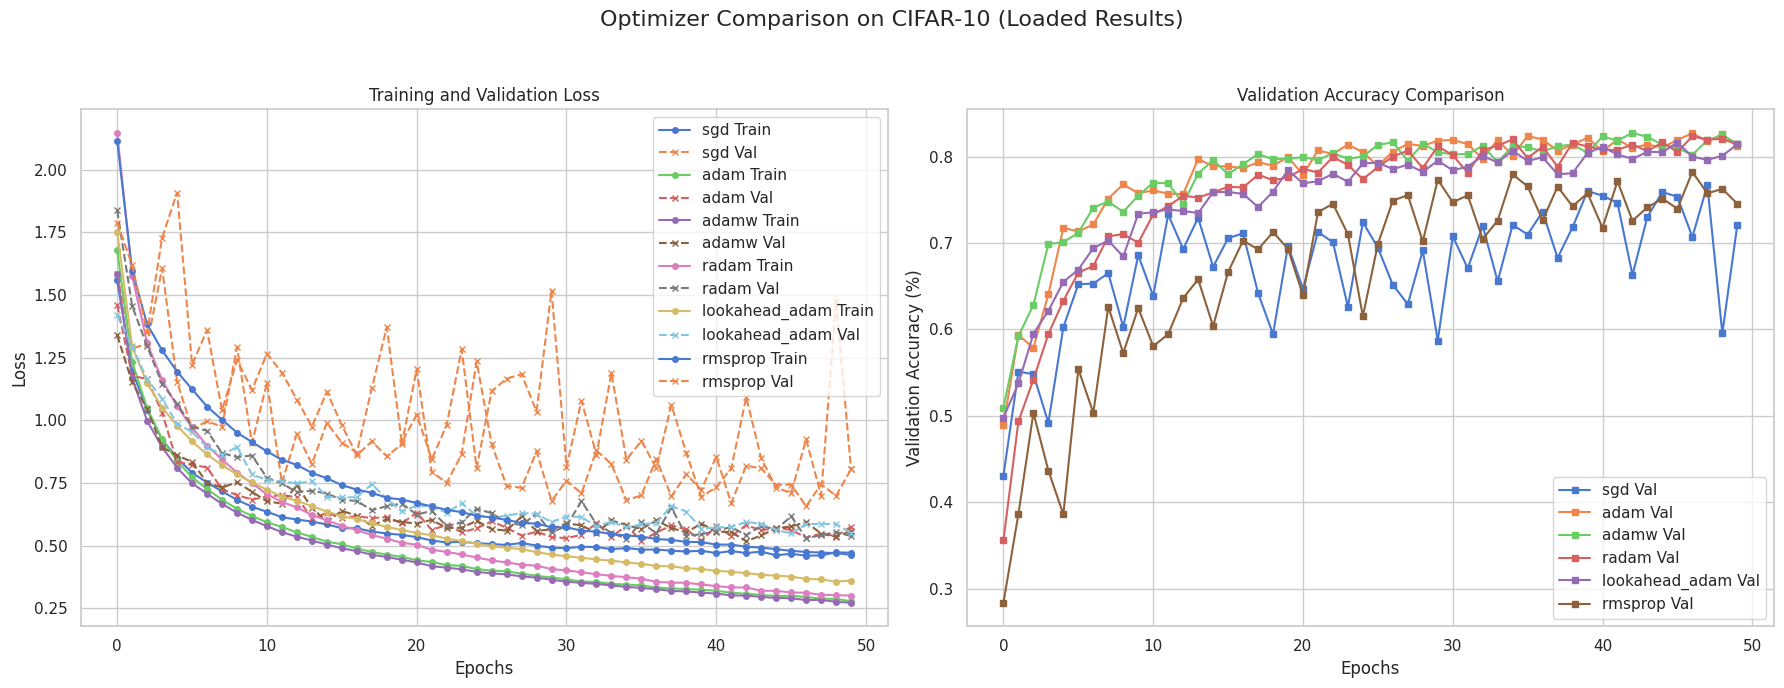

In [24]:
# %% Load and Visualize Results
import matplotlib.pyplot as plt
%matplotlib inline

# Load saved results
history = load_experiment('cifar_optim_custom.pth')

# Create visualization
plt.figure(figsize=(12, 6))
visualize_performance(
    history,
    title='Optimizer Comparison on CIFAR-10 (Loaded Results)',
    save_path='results/final_comparison.png'
)
plt.show()

/tmp/ipykernel_2249645/3411134192.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(filename)


=== Final Validation Accuracy Comparison ===
SGD             | Final: 0.7208 | Mean ± Std: 0.7087 ± 0.0605
ADAM            | Final: 0.8116 | Mean ± Std: 0.8202 ± 0.0057
ADAMW           | Final: 0.8150 | Mean ± Std: 0.8140 ± 0.0077
RADAM           | Final: 0.8140 | Mean ± Std: 0.8165 ± 0.0064
LOOKAHEAD_ADAM  | Final: 0.8142 | Mean ± Std: 0.8054 ± 0.0081
RMSPROP         | Final: 0.7454 | Mean ± Std: 0.7574 ± 0.0149

=== Conclusion ===
Best Optimizer: ADAM with mean accuracy 0.8202 ± 0.0057


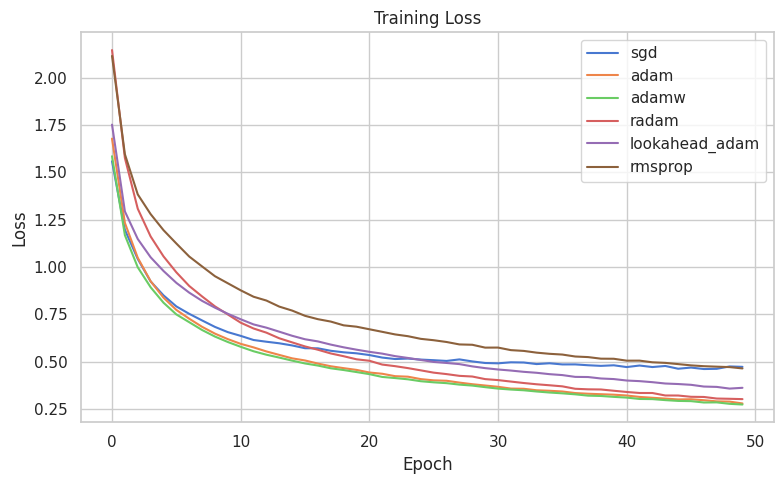

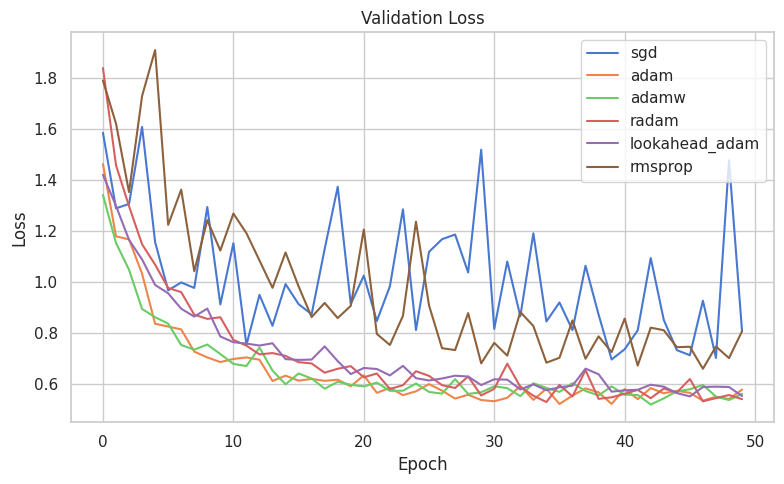

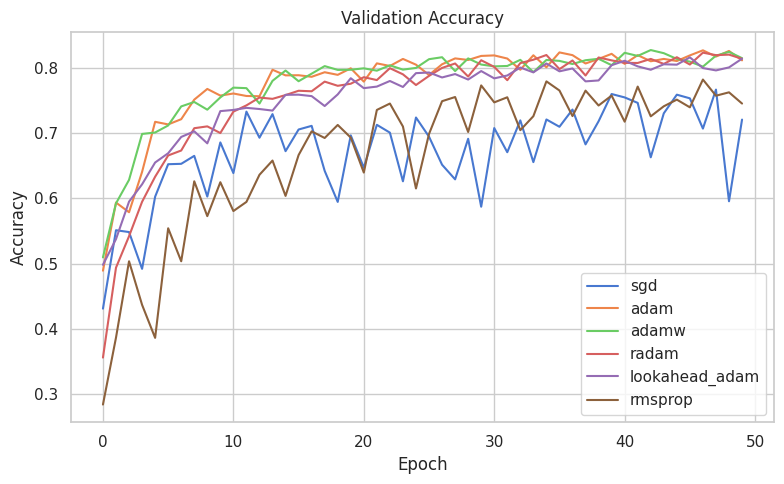


✅ Recommendation: 'adam' showed the best performance based on validation accuracy consistency and final performance.


In [29]:
import matplotlib.pyplot as plt
import torch
import numpy as np
import os

# Load saved results
def load_experiment(filename):
    return torch.load(filename)

# Plotting helper
def plot_metric(history, key, title, ylabel):
    plt.figure(figsize=(8, 5))
    for name, data in history.items():
        if key in data:
            plt.plot(data[key], label=name)
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Analyze results numerically
def analyze_results(history):
    print("=== Final Validation Accuracy Comparison ===")
    results = []
    
    for opt_name, data in history.items():
        final_val_acc = data['val_acc'][-1]  # Last epoch accuracy
        mean_val_acc = np.mean(data['val_acc'][-5:])  # Avg of last 5 epochs
        std_val_acc = np.std(data['val_acc'][-5:])
        
        results.append({
            'name': opt_name,
            'final': final_val_acc,
            'mean': mean_val_acc,
            'std': std_val_acc
        })
        
        print(f"{opt_name.upper():<15} | "
              f"Final: {final_val_acc:.4f} | "
              f"Mean ± Std: {mean_val_acc:.4f} ± {std_val_acc:.4f}")

    # Best optimizer based on mean accuracy of last 5 epochs
    best = max(results, key=lambda x: x['mean'])
    print("\n=== Conclusion ===")
    print(f"Best Optimizer: {best['name'].upper()} with "
          f"mean accuracy {best['mean']:.4f} ± {best['std']:.4f}")

    return best['name']

# Full visualizations
def visualize_all_metrics(history):
    plot_metric(history, key='train_loss', title='Training Loss', ylabel='Loss')
    plot_metric(history, key='val_loss', title='Validation Loss', ylabel='Loss')
    # plot_metric(history, key='train_acc', title='Training Accuracy', ylabel='Accuracy')
    plot_metric(history, key='val_acc', title='Validation Accuracy', ylabel='Accuracy')

if __name__ == "__main__":
    path = '/home/shubham24165/AOMML_A3/results_CustomOptim_CIFAR10/cifar_optim_custom.pth'
    
    if not os.path.exists(path):
        print(f"Error: File not found at {path}")
    else:
        history = load_experiment(path)
        best_optimizer = analyze_results(history)
        visualize_all_metrics(history)
        
        print(f"\n✅ Recommendation: '{best_optimizer}' showed the best performance "
              "based on validation accuracy consistency and final performance.")